# 심층 분석: 커널 밀도 추정

이전 장에서 우리는 클러스터링 추정기와 밀도 추정기의 일종의 하이브리드인 가우스 혼합 모델을 다루었습니다.
밀도 추정기는 $D$ 차원 데이터 세트를 가져와서 데이터가 추출되는 $D$ 차원 확률 분포의 추정치를 생성하는 알고리즘이라는 점을 기억하세요.
GMM 알고리즘은 밀도를 가우스 분포의 가중 합으로 표현하여 이를 수행합니다.
*커널 밀도 추정*(KDE)은 어떤 의미에서는 가우스 혼합 아이디어를 논리적 극단으로 끌어올리는 알고리즘입니다. 즉, *포인트당* 하나의 가우스 구성 요소로 구성된 혼합을 사용하여 본질적으로 비모수적 밀도 추정기를 생성합니다.
이번 장에서는 KDE의 동기와 용도를 살펴보겠습니다.

표준 가져오기부터 시작합니다.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
import numpy as np

## 커널 밀도 추정 동기 부여: 히스토그램

앞서 언급했듯이 밀도 추정기는 데이터 세트를 생성한 확률 분포를 모델링하려는 알고리즘입니다.
1차원 데이터의 경우 아마도 이미 하나의 간단한 밀도 추정기인 히스토그램에 익숙할 것입니다.
히스토그램은 데이터를 개별 빈으로 나누고 각 빈에 속하는 포인트 수를 계산한 다음 직관적인 방식으로 결과를 시각화합니다.

예를 들어 두 정규 분포에서 추출된 일부 데이터를 만들어 보겠습니다.

In [2]:
def make_data(N, f=0.3, rseed=1):
    rand = np.random.RandomState(rseed)
    x = rand.randn(N)
    x[int(f * N):] += 5
    return x

x = make_data(1000)

우리는 이전에 `plt.hist` 함수를 사용하여 표준 개수 기반 히스토그램을 만들 수 있다는 것을 살펴보았습니다.
히스토그램의 '밀도' 매개변수를 지정하면 빈의 높이가 개수를 반영하지 않고 대신 확률 밀도를 반영하는 정규화된 히스토그램이 생성됩니다(다음 그림 참조).

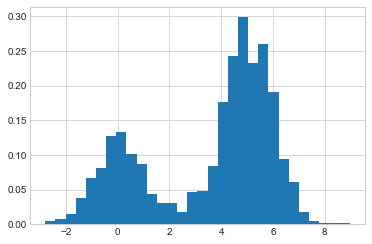

In [3]:
hist = plt.hist(x, bins=30, density=True)

동일한 비닝의 경우 이 정규화는 단순히 y축의 배율만 변경하고 상대 높이는 개수로 구성된 히스토그램과 동일하게 유지됩니다.
이 정규화는 히스토그램 함수의 출력을 보면 확인할 수 있듯이 히스토그램 아래의 전체 영역이 1이 되도록 선택됩니다.

In [4]:
density, bins, patches = hist
widths = bins[1:] - bins[:-1]
(density * widths).sum()

1.0

히스토그램을 밀도 추정기로 사용할 때 발생하는 문제 중 하나는 빈 크기와 위치를 선택하면 질적으로 다른 특징을 갖는 표현이 나올 수 있다는 것입니다.
예를 들어 포인트가 20개뿐인 이 데이터 버전을 보면 구간을 그리는 방법을 선택하면 데이터가 완전히 다르게 해석될 수 있습니다.
다음 그림에 시각화된 이 예를 고려해 보세요.

In [5]:
x = make_data(20)
bins = np.linspace(-5, 10, 10)

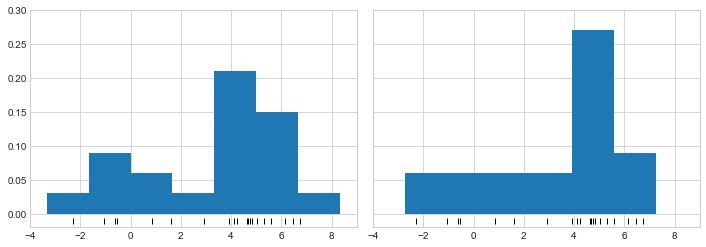

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4),
                       sharex=True, sharey=True,
                       subplot_kw={'xlim':(-4, 9),
                                   'ylim':(-0.02, 0.3)})
fig.subplots_adjust(wspace=0.05)
for i, offset in enumerate([0.0, 0.6]):
    ax[i].hist(x, bins=bins + offset, density=True)
    ax[i].plot(x, np.full_like(x, -0.01), '|k',
               markeredgewidth=1)

왼쪽의 히스토그램을 보면 이것이 이봉 분포임을 분명히 확인합니다.
오른쪽에는 긴 꼬리를 갖는 단봉 분포가 표시됩니다.
앞의 코드를 보지 않고서는 이 두 히스토그램이 동일한 데이터에서 작성되었다는 것을 짐작하지 못할 것입니다. 이를 염두에 두고 히스토그램이 제공하는 직관을 어떻게 신뢰할 수 있습니까?
그리고 이를 어떻게 개선할 수 있을까요?

한발 물러서서 히스토그램을 블록 스택으로 생각합니다. 여기서 데이터 세트의 각 지점 위에 있는 각 빈 내에 하나의 블록을 쌓습니다.
이를 직접 살펴보겠습니다(다음 그림 참조).

(-0.2, 8.0)

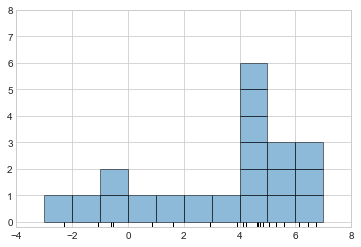

In [7]:
fig, ax = plt.subplots()
bins = np.arange(-3, 8)
ax.plot(x, np.full_like(x, -0.1), '|k',
        markeredgewidth=1)
for count, edge in zip(*np.histogram(x, bins)):
    for i in range(count):
        ax.add_patch(plt.Rectangle(
            (edge, i), 1, 1, ec='black', alpha=0.5))
ax.set_xlim(-4, 8)
ax.set_ylim(-0.2, 8)

두 개의 비닝의 문제는 블록 스택의 높이가 근처 포인트의 실제 밀도가 아니라 빈이 데이터 포인트와 정렬되는 방식의 일치를 반영하는 경우가 많다는 사실에서 비롯됩니다.
포인트와 해당 블록 간의 이러한 정렬 불량은 여기에 표시된 히스토그램 결과가 좋지 않은 잠재적인 원인입니다.
하지만 *빈*에 정렬된 블록을 쌓는 대신 *빈이 나타내는 지점*에 정렬된 블록을 쌓으면 어떻게 될까요?
이렇게 하면 블록이 정렬되지 않지만 x축을 따라 각 위치에 기여도를 추가하여 결과를 찾을 수 있습니다.
이것을 시도해 보겠습니다(다음 그림 참조).

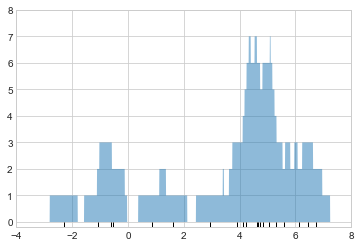

In [8]:
x_d = np.linspace(-4, 8, 2000)
density = sum((abs(xi - x_d) < 0.5) for xi in x)

plt.fill_between(x_d, density, alpha=0.5)
plt.plot(x, np.full_like(x, -0.1), '|k', markeredgewidth=1)

plt.axis([-4, 8, -0.2, 8]);

결과는 약간 지저분해 보이지만 표준 히스토그램보다 실제 데이터 특성을 훨씬 더 강력하게 반영합니다.
그러나 거친 가장자리는 미적으로 보기 좋지 않으며 데이터의 실제 속성을 반영하지도 않습니다.
이를 부드럽게 하기 위해 각 위치의 블록을 가우스와 같은 부드러운 함수로 대체하기로 결정합니다.
블록 대신 각 점에서 표준 정규 곡선을 사용해 보겠습니다(다음 그림 참조).

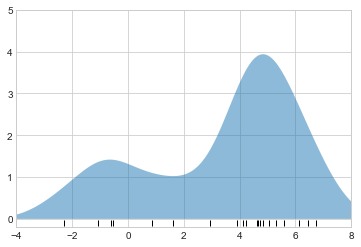

In [9]:
from scipy.stats import norm
x_d = np.linspace(-4, 8, 1000)
density = sum(norm(xi).pdf(x_d) for xi in x)

plt.fill_between(x_d, density, alpha=0.5)
plt.plot(x, np.full_like(x, -0.1), '|k', markeredgewidth=1)

plt.axis([-4, 8, -0.2, 5]);

각 입력 지점의 위치에 가우스 분포가 기여된 이 평활화된 플롯은 데이터 분포의 모양에 대한 훨씬 더 정확한 아이디어를 제공하며 분산이 훨씬 적습니다(즉, 샘플링 차이에 대한 응답으로 훨씬 덜 변경됨).

마지막 두 플롯에서 우리가 착안한 것은 일차원의 커널 밀도 추정입니다. 전자의 경우 정사각형 또는 "tophat" 모양의 커널, 후자의 경우 가우시안 커널인 "커널"을 각 지점의 위치에 배치하고 그 합을 밀도 추정치로 사용했습니다.
이러한 직관을 염두에 두고 이제 커널 밀도 추정을 더 자세히 살펴보겠습니다.

## 실제 커널 밀도 추정

커널 밀도 추정의 자유 매개변수는 각 점에 배치된 분포의 모양을 지정하는 *커널*과 각 점에서 커널의 크기를 제어하는 ​​*커널 대역폭*입니다.
실제로 커널 밀도 추정에 사용할 수 있는 커널은 많습니다. 특히 Scikit-Learn KDE 구현은 문서의 ["밀도 추정" 섹션](http://scikit-learn.org/stable/modules/density.html)에서 읽을 수 있는 6개의 커널을 지원합니다.

파이썬(Python)으로 구현된 여러 버전의 KDE가 있지만(특히 SciPy 및 `statsmodels` 패키지) 저는 효율성과 유연성 때문에 Scikit-Learn 버전을 사용하는 것을 선호합니다.
이는 6개 커널 중 하나와 수십 개의 거리 측정 항목 중 하나를 사용하여 다차원에서 KDE를 처리하는 `sklearn.neighbors.KernelDensity` 추정기에서 구현됩니다.
KDE는 상당히 계산 집약적일 수 있기 때문에 Scikit-Learn 추정기는 내부적으로 트리 기반 알고리즘을 사용하고 `atol`(절대 허용오차) 및 `rtol`(상대 허용오차) 매개변수를 사용하여 정확도를 위해 계산 시간을 절충합니다.
곧 살펴보겠지만 Scikit-Learn의 표준 교차 검증 도구를 사용하여 커널 대역폭을 결정합니다.

먼저 Scikit-Learn `KernelDensity` 추정기를 사용하여 이전 플롯을 복제하는 간단한 예를 보여드리겠습니다(다음 그림 참조).

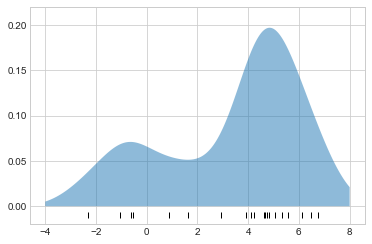

In [10]:
from sklearn.neighbors import KernelDensity

# instantiate and fit the KDE model
kde = KernelDensity(bandwidth=1.0, kernel='gaussian')
kde.fit(x[:, None])

# score_samples returns the log of the probability density
logprob = kde.score_samples(x_d[:, None])

plt.fill_between(x_d, np.exp(logprob), alpha=0.5)
plt.plot(x, np.full_like(x, -0.01), '|k', markeredgewidth=1)
plt.ylim(-0.02, 0.22);

여기의 결과는 곡선 아래 면적이 1이 되도록 정규화됩니다.

## 교차 검증을 통해 대역폭 선택

KDE 절차에 의해 생성된 최종 추정치는 밀도 추정에서 편향-분산 균형을 제어하는 ​​손잡이인 대역폭 선택에 매우 민감합니다.
대역폭이 너무 좁으면 단일 지점의 존재 여부에 따라 큰 차이가 발생하는 높은 분산 추정(즉, 과적합)이 발생합니다. 대역폭이 너무 넓으면 높은 편향 추정(즉, 과소적합)이 발생하여 데이터의 구조가 넓은 커널에 의해 씻겨 나가게 됩니다.

데이터에 대한 다소 엄격한 가정을 기반으로 최상의 대역폭을 신속하게 추정하는 방법에 대한 통계의 오랜 역사가 있습니다. 예를 들어 SciPy 및 `statsmodels` 패키지에서 KDE 구현을 찾아보면 이러한 규칙 중 일부를 기반으로 한 구현을 살펴볼 수 있습니다.

머신러닝(Machine Learning) 맥락에서 우리는 이러한 초매개변수 조정이 교차 검증 접근 방식을 통해 경험적으로 수행되는 경우가 많다는 것을 확인했습니다.
이를 염두에 두고 Scikit-Learn의 'KernelDensity' 추정기는 패키지의 표준 그리드 검색 도구 내에서 직접 사용할 수 있도록 설계되었습니다.
여기서는 `GridSearchCV`를 사용하여 이전 데이터 세트의 대역폭을 최적화합니다.
우리는 이렇게 작은 데이터 세트를 보고 있기 때문에 각 교차 검증 시도에 대한 훈련 세트 크기의 감소를 최소화하는 Leave-One-Out 교차 검증을 사용할 것입니다.

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import LeaveOneOut

bandwidths = 10 ** np.linspace(-1, 1, 100)
grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                    {'bandwidth': bandwidths},
                    cv=LeaveOneOut())
grid.fit(x[:, None]);

이제 점수를 최대화하는 대역폭 선택을 찾을 수 있습니다(이 경우 기본값은 로그 우도입니다).

In [12]:
grid.best_params_

{'bandwidth': 1.1233240329780276}

최적의 대역폭은 대역폭이 1.0(즉, `scipy.stats.norm`의 기본 너비)인 이전 예제 플롯에서 사용한 것과 매우 가깝습니다.

## 예: 그다지 순진하지 않은 베이즈

이 예에서는 KDE를 사용한 베이지안 생성 분류를 살펴보고 Scikit-Learn 아키텍처를 사용하여 사용자 정의 추정기를 만드는 방법을 보여줍니다.

[심층: Naive Bayes Classification](05.05-Naive-Bayes.ipynb)에서는 각 클래스에 대한 간단한 생성 모델을 생성하고 이러한 모델을 사용하여 빠른 분류기를 구축하는 순진한 베이지안 분류를 살펴보았습니다.
Gaussian Naive Bayes의 경우 생성 모델은 단순 축 정렬 가우스입니다.
KDE와 같은 밀도 추정 알고리즘을 사용하면 "순진한" 요소를 제거하고 각 클래스에 대해 보다 정교한 생성 모델을 사용하여 동일한 분류를 수행합니다.
여전히 베이지안 분류이지만 더 이상 순진하지 않습니다.

생성 분류에 대한 일반적인 접근 방식은 다음과 같습니다.

1. 훈련 데이터를 레이블별로 분할합니다.

2. 각 세트에 대해 KDE를 피팅하여 데이터 생성 모델을 얻습니다.
이를 통해 모든 관찰 $x$ 및 레이블 $y$에 대해 $P(x~|~y)$ 가능성을 계산합니다.
   
3. 훈련 세트에 있는 각 클래스의 예 수에서 *사전 클래스* $P(y)$를 계산합니다.

4. 알려지지 않은 점 $x$에 대해 각 클래스의 사후 확률은 $P(y~|~x) \propto P(x~|~y)P(y)$입니다.
이 사후를 최대화하는 클래스는 점에 할당된 레이블입니다.

알고리즘은 이해하기 간단하고 직관적입니다. 더 어려운 부분은 그리드 검색 및 교차 검증 아키텍처를 활용하기 위해 Scikit-Learn 프레임워크 내에 이를 배치하는 것입니다.

이것은 Scikit-Learn 프레임워크 내에서 알고리즘을 구현하는 코드입니다. 코드 블록을 따라 단계별로 살펴보겠습니다.

In [13]:
from sklearn.base import BaseEstimator, ClassifierMixin


class KDEClassifier(BaseEstimator, ClassifierMixin):
    """Bayesian generative classification based on KDE
    
    Parameters
    ----------
    bandwidth : float
        the kernel bandwidth within each class
    kernel : str
        the kernel name, passed to KernelDensity
    """
    def __init__(self, bandwidth=1.0, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel
        
    def fit(self, X, y):
        self.classes_ = np.sort(np.unique(y))
        training_sets = [X[y == yi] for yi in self.classes_]
        self.models_ = [KernelDensity(bandwidth=self.bandwidth,
                                      kernel=self.kernel).fit(Xi)
                        for Xi in training_sets]
        self.logpriors_ = [np.log(Xi.shape[0] / X.shape[0])
                           for Xi in training_sets]
        return self
        
    def predict_proba(self, X):
        logprobs = np.array([model.score_samples(X)
                             for model in self.models_]).T
        result = np.exp(logprobs + self.logpriors_)
        return result / result.sum(axis=1, keepdims=True)
        
    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), 1)]

### 맞춤 추정기 분석

이 코드를 단계별로 살펴보고 필수 기능에 대해 논의해 보겠습니다.

``파이썬
sklearn.base에서 BaseEstimator, ClassifierMixin 가져오기

클래스 KDEClassifier(BaseEstimator, ClassifierMixin):
"""KDE 기반 베이지안 생성 분류
    
매개변수
    ----------
대역폭 : 부동
각 클래스 내의 커널 대역폭
커널 : str
KernelDensity에 전달된 커널 이름
    """
````

Scikit-Learn의 각 추정기는 클래스이며, 이 클래스는 'BaseEstimator' 클래스와 표준 기능을 제공하는 적절한 믹스인에서 상속하는 것이 가장 편리합니다.
예를 들어 여기서 `BaseEstimator`에는 교차 검증 절차에 사용하기 위해 추정기를 복제/복사하는 데 필요한 논리가 포함되어 있으며 `ClassifierMixin`은 이러한 루틴에서 사용되는 기본 `score` 방법을 정의합니다.
또한 IPython의 도움말 기능으로 캡처되는 독스트링도 제공합니다([IPython의 도움말과 문서](01.01-Help-And-Documentation.ipynb) 참조).

다음은 클래스 초기화 방법입니다.

``파이썬
def __init__(self, 대역폭=1.0, 커널='가우스'):
self.bandwidth = 대역폭
self.kernel = 커널
````

이는 객체가 `KDEClassifier`로 인스턴스화될 때 실행되는 실제 코드입니다.
Scikit-Learn에서는 *초기화에는 전달된 값을 `self`에 이름으로 할당하는 것 외에 다른 작업이 포함되지 않는다는 것이 중요합니다*.
이는 교차 검증, 그리드 검색 및 기타 기능을 위한 추정기를 복제하고 수정하는 데 필요한 'BaseEstimator'에 포함된 논리 때문입니다.
마찬가지로 `__init__`에 대한 모든 인수는 명시적이어야 합니다. 즉, `*args` 또는 `**kwargs`는 교차 검증 루틴 내에서 올바르게 처리되지 않으므로 피해야 합니다.

다음은 학습 데이터를 처리하는 'fit' 메서드입니다.

``파이썬
def fit(self, X, y):
self.classes_ = np.sort(np.unique(y))
training_sets = [self.classes_의 yi에 대한 X[y == yi]]
self.models_ = [KernelDensity(대역폭=self.bandwidth,
커널=self.kernel).fit(Xi)
training_sets의 Xi용]
self.logpriors_ = [np.log(Xi.shape[0] / X.shape[0])
training_sets의 Xi용]
자기 자신을 돌려보내다
````

여기에서는 훈련 데이터에서 고유한 클래스를 찾고, 각 클래스에 대해 `KernelDensity` 모델을 훈련하고, 입력 샘플 수를 기반으로 클래스 사전율을 계산합니다.
마지막으로 'fit'은 명령을 연결할 수 있도록 항상 'self'를 반환해야 합니다. 예를 들어:
``파이썬
레이블 = model.fit(X, y).predict(X)
````
각 피팅의 지속적인 결과는 후행 밑줄(예: `self.logpriors_`)과 함께 저장됩니다.
이는 추정기의 멤버를 빠르게 스캔하고(IPython의 탭 완성 기능을 사용하여) 훈련 데이터에 적합한 멤버를 정확히 확인할 수 있도록 Scikit-Learn에서 사용되는 규칙입니다.

마지막으로 새 데이터에 대한 레이블을 예측하는 논리가 있습니다.
``파이썬
def 예측_프로바(self, X):
logprobs = np.vstack([model.score_samples(X))
self.models_]).T의 모델용
결과 = np.exp(logprobs + self.logpriors_)
결과 / 결과를 반환합니다.sum(axis=1, keepdims=True)
        
def 예측(self, X):
self.classes_[np.argmax(self.predict_proba(X), 1)] 반환
````
이는 확률적 분류기이므로 먼저 '[n_samples, n_classes]' 형태의 클래스 확률 배열을 반환하는 'predict_proba'를 구현합니다.
이 배열의 항목 `[i, j]`는 샘플 `i`가 `j` 클래스의 구성원일 사후 확률로, 우도에 사전 클래스를 곱하고 정규화하여 계산됩니다.

'predict' 메서드는 이러한 확률을 사용하고 가장 큰 확률을 가진 클래스를 반환합니다.

### 맞춤 견적 도구 사용

이전에 본 문제인 손으로 쓴 숫자 분류에 대해 이 사용자 정의 추정기를 사용해 보겠습니다.
여기에서는 ``GridSearchCV`` 메타 추정기를 사용하여 숫자를 로드하고 다양한 후보 대역폭에 대한 교차 검증 점수를 계산합니다([하이퍼파라미터 및 모델 검증](05.03-Hyperparameters-and-Model-Validation.ipynb) 참조).

In [14]:
from sklearn.datasets import load_digits
from sklearn.model_selection import GridSearchCV

digits = load_digits()

grid = GridSearchCV(KDEClassifier(),
                    {'bandwidth': np.logspace(0, 2, 100)})
grid.fit(digits.data, digits.target);

다음으로 교차 검증 점수를 대역폭의 함수로 표시합니다(다음 그림 참조).

best param: {'bandwidth': 6.135907273413174}
accuracy = 0.9677298050139276


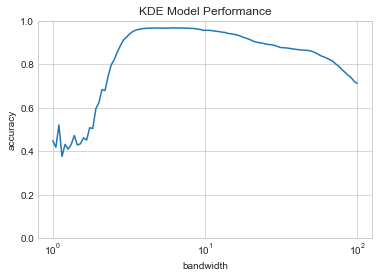

In [15]:
fig, ax = plt.subplots()
ax.semilogx(np.array(grid.cv_results_['param_bandwidth']),
            grid.cv_results_['mean_test_score'])
ax.set(title='KDE Model Performance', ylim=(0, 1),
       xlabel='bandwidth', ylabel='accuracy')
print(f'best param: {grid.best_params_}')
print(f'accuracy = {grid.best_score_}')

이는 Naive Bayes 분류기의 교차 검증 정확도가 약 80%인 것과 비교하여 KDE 분류기가 96% 이상의 교차 검증 정확도에 도달했음을 나타냅니다.

In [16]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
cross_val_score(GaussianNB(), digits.data, digits.target).mean()

0.8069281956050759

이러한 생성 분류기의 한 가지 이점은 결과의 해석 가능성입니다. 각각의 알려지지 않은 샘플에 대해 확률적 분류뿐만 아니라 비교하는 포인트 분포의 *전체 모델*을 얻을 수 있습니다!
원하는 경우 이는 SVM 및 랜덤 포레스트와 같은 알고리즘이 모호해지는 경향이 있는 특정 분류의 이유에 대한 직관적인 창을 제공합니다.

더 나아가 KDE 분류기 모델을 개선할 수 있는 몇 가지 아이디어를 소개합니다:

- 각 클래스의 대역폭을 독립적으로 변경합니다.
- 예측 점수를 기준으로 하지 않고 각 클래스 내의 생성 모델에 따른 훈련 데이터의 가능성을 기준으로 이러한 대역폭을 최적화합니다(즉, 전체 예측 정확도 대신 'KernelDensity' 자체의 점수를 사용함).

마지막으로, 자신만의 추정기를 만드는 연습을 하고 싶다면 KDE 대신 가우스 혼합 모델을 사용하여 유사한 베이지안 분류기를 만드는 것을 시도해 살펴볼 수 있습니다.